In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np


In [42]:
df=pd.read_csv('data/nobel.csv')
print(df.head())

   year    category  ... death_city death_country
0  1901   Chemistry  ...     Berlin       Germany
1  1901  Literature  ...   Châtenay        France
2  1901    Medicine  ...    Marburg       Germany
3  1901       Peace  ...     Heiden   Switzerland
4  1901       Peace  ...      Paris        France

[5 rows x 18 columns]


In [43]:
df.shape

(1000, 18)

In [44]:
df.isna().sum()

year                      0
category                  0
prize                     0
motivation               88
prize_share               0
laureate_id               0
laureate_type             0
full_name                 0
birth_date               32
birth_city               36
birth_country            31
sex                      30
organization_name       264
organization_city       265
organization_country    265
death_date              404
death_city              421
death_country           415
dtype: int64

In [45]:
df1 = df.fillna('Unknown')


In [46]:
print(df1)

     year    category  ... death_city death_country
0    1901   Chemistry  ...     Berlin       Germany
1    1901  Literature  ...   Châtenay        France
2    1901    Medicine  ...    Marburg       Germany
3    1901       Peace  ...     Heiden   Switzerland
4    1901       Peace  ...      Paris        France
..    ...         ...  ...        ...           ...
995  2023   Chemistry  ...    Unknown       Unknown
996  2023   Chemistry  ...    Unknown       Unknown
997  2023  Literature  ...    Unknown       Unknown
998  2023       Peace  ...    Unknown       Unknown
999  2023   Economics  ...    Unknown       Unknown

[1000 rows x 18 columns]


In [47]:
top_gender = df1['sex'].value_counts().index[0]
top_country = df1['birth_country'].value_counts().index[0]
print(top_country)
print(top_gender)

United States of America
Male


In [58]:
df1['usa_born_prize'] = df1['birth_country'] == 'United States of America'
df1['decade'] = (np.floor(df1['year'] / 10) * 10).astype(int)
decade_usa = df1.groupby('decade', as_index=False)['usa_born_prize'].mean()
max_decade_usa = decade_usa.idxmax()
print(max_decade_usa)

decade            12
usa_born_prize    10
dtype: int64


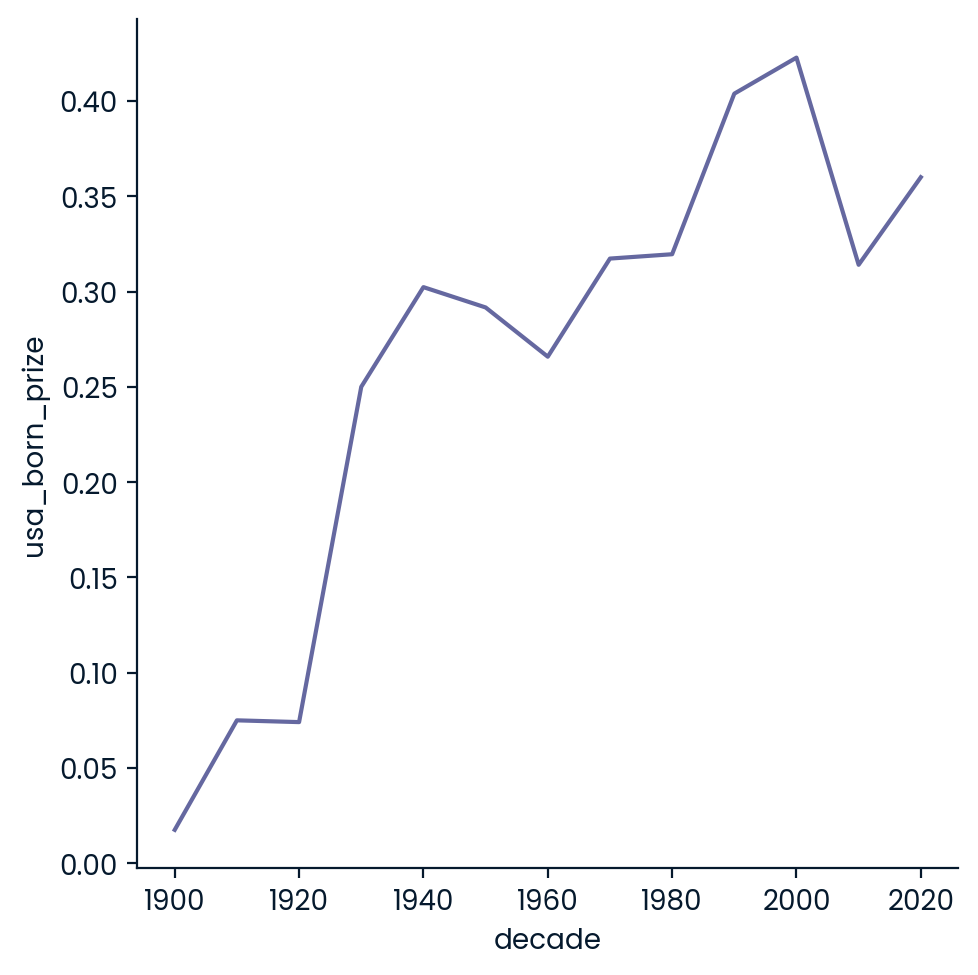

In [49]:
ax1 = sns.relplot(x='decade',y='usa_born_prize',data =decade_usa, kind='line' )

In [50]:
df1['female_laurate'] = df1['sex'] == 'Female'
female_winner = df1.groupby(['decade','category'], as_index=False)['female_laurate'].mean()
print(female_winner)

    decade    category  female_laurate
0     1900   Chemistry        0.000000
1     1900  Literature        0.100000
2     1900    Medicine        0.000000
3     1900       Peace        0.071429
4     1900     Physics        0.076923
..     ...         ...             ...
67    2020   Economics        0.111111
68    2020  Literature        0.500000
69    2020    Medicine        0.125000
70    2020       Peace        0.285714
71    2020     Physics        0.166667

[72 rows x 3 columns]


In [51]:
female_winner_category = female_winner[female_winner['female_laurate'] == female_winner['female_laurate'].max()][['decade','category']]
max_female_dict = {female_winner_category['decade'].values[0] : female_winner_category['category'].values[0]}
print(max_female_dict)

{2020: 'Literature'}


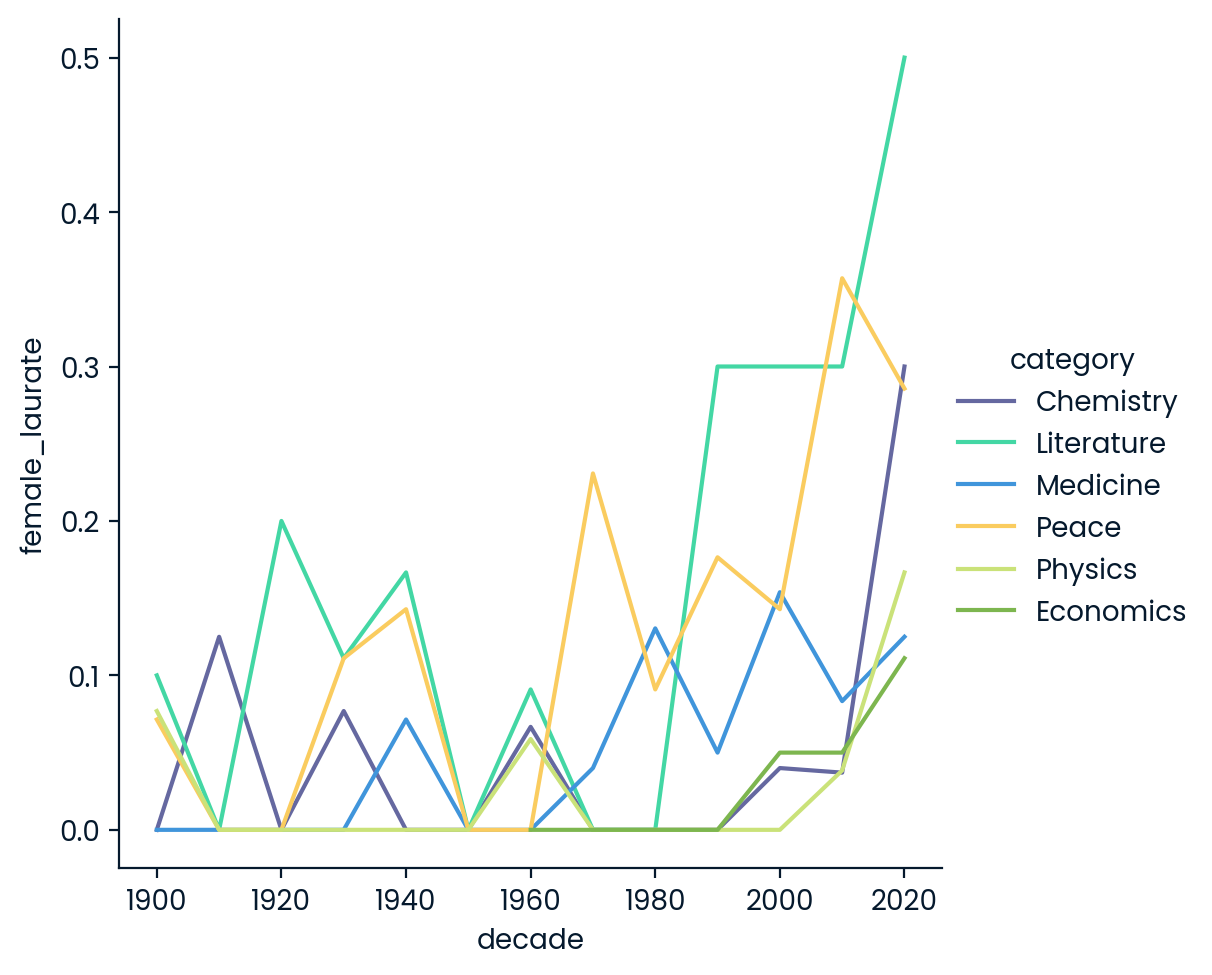

In [52]:
ax2 = sns.relplot(x='decade', y='female_laurate', hue='category', data=female_winner, kind="line")

In [53]:
nobel_winner =df1[df1['female_laurate']]
min_year_winner = nobel_winner[nobel_winner['year'] == nobel_winner['year'].min()]
first_woman_name = min_year_winner['full_name'].values[0]
first_woman_category = min_year_winner['category'].values[0]
print(first_woman_name)
print(first_woman_category)

Marie Curie, née Sklodowska
Physics


In [54]:
count= df1['full_name'].value_counts()
repeat = count[count >= 2].index
repeat_list = list(repeat)
print(repeat_list)

['Comité international de la Croix Rouge (International Committee of the Red Cross)', 'Linus Carl Pauling', 'John Bardeen', 'Frederick Sanger', 'Marie Curie, née Sklodowska', 'Office of the United Nations High Commissioner for Refugees (UNHCR)']
